In [ ]:
#导入必须库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams				#字体设置
import matplotlib.dates as mdates			#处理日期坐标轴
import seaborn as sns
from E0324_main import *
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
rcParams ['font.sans-serif'] = ['Microsoft YaHei']	#设置微软雅黑
plt.rcParams['axes.unicode_minus'] = False	#正常显示负号

In [ ]:
#导入数据
df = pd.read_csv(r'C:\Users\ASUS\Project\Project\data\house_sales.csv')

In [ ]:
#数据清洗
    #删除无用列
df.drop(columns='origin_url',inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
#面积转换
df['area'] = df['area'].str.replace('㎡','').astype(float)
#售价转换
df['price'] = df['price'].str.replace('万','').astype(float)
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)
df['toward'] = df['toward'].astype('category')
df['year'] = df['year'].str.replace('年建','').astype(int)

In [ ]:
#异常值处理
#房屋面积异常值
print('-'*50)
df = df[(df['area']<600) & (df['area']>20)]
print(len(df))
#房屋售价异常值
Q1 = df['price'].quantile(0.25)                             #利用IQR找出异常值
Q3 = df['price'].quantile(0.75)
IQR = Q3-Q1
low_price = Q1 - 1.5*IQR
high_price = Q3 + 1.5*IQR
df = df[(df['price']<high_price) & (df['price']>low_price)]

In [ ]:
#新数据特征构造
#地区district
df['district'] = df['address'].str.split('-').str[0]    #这里str[0]是pandas专用取指定列
#楼层类型floor_type
df['floor_type'] = df['floor'].apply(fun1).astype('category')    #把一个函数批量作用到一整列的每一个元素上
#是否是直辖市zxs
df['zxs'] = df['province'].apply(lambda x:fun2(x))
#卧室数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0]
#客厅数量livingrooms
#df['livingrooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0]
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅')
#楼龄building_age
df['building_age'] = 2025 - df['year']
#价格分段price_labels
labels = ['低价','中价','高价','豪华']
df['price_labels'] = pd.cut(df['price'],
       bins = 4,
       labels = labels)

In [ ]:
#数据分析
'''
问题编号：A1
问题：哪些变量最影响房价？面积、楼层、房间数哪个影响更大？
分析主题：特征相关性
分析目标：了解房屋各特征对房价的线性影响
分组字段：无
指标 / 方法：皮尔逊相关系数
'''
#选择数值型特征
question1 = df[['price', 'area', 'unit', 'building_age']].corr()
#question1['price'].sort_values(ascending=False)[1:]
#相关性热力图
plt.figure(figsize=(10,6))
sns.heatmap(data=question1,cmap='coolwarm',vmin=0,vmax=1,annot=True,annot_kws={'size':10})

In [ ]:
'''
问题编号：A2
问题：全国房价总体分布是怎样的？是否存在极端值？
分析主题：描述性统计
分析目标：概览数值型字段的分布特征
分组字段：无
指标/方法：平均数 / 中位数 / 四分位数 / 标准差
'''
df.describe()
#房价分布直方图
plt.subplot(221)
plt.hist(df['price'], bins=10)
plt.title('房价分布直方图1')
plt.subplot(222)
sns.histplot(data=df, x='price',bins = 10,kde=True)
plt.title('房价分布直方图2')

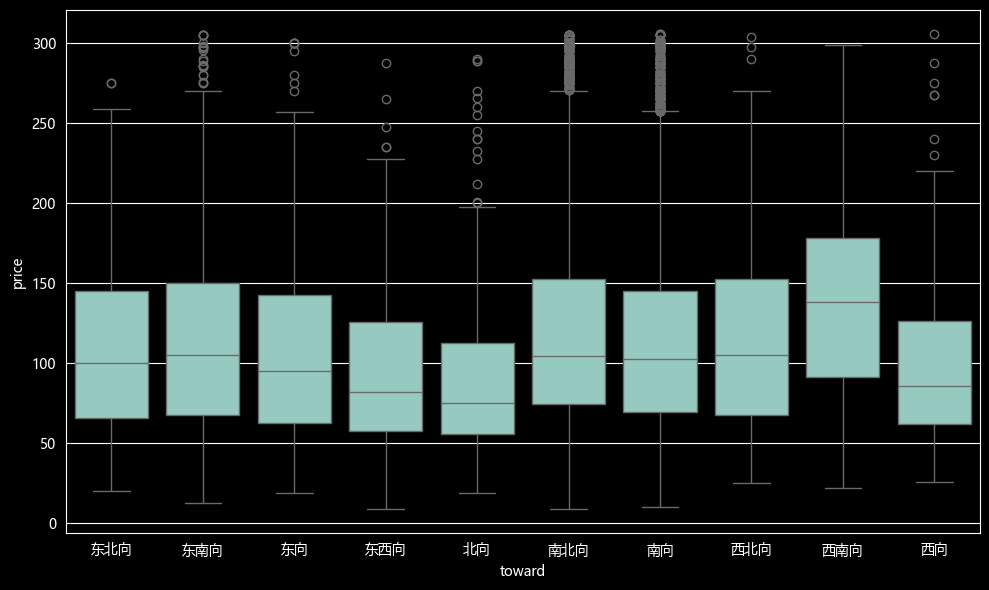

In [49]:
'''
问题编号：A6
问题：南北向是否真比单一朝向贵？贵多少？
分析主题：朝向溢价
分析目标：评估不同朝向的价格差异
分组字段：toward
指标 / 方法：方差分析 / 多重比较
'''
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'median',
    'building_age':'mean',
})
plt.figure(figsize=(10,6))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout()
plt.show()

In [ ]:
#数据概览
print(df.info())
print('-'*50)
df.sample(10)